In [22]:
import numpy as np
import awkward as ak
from collections import defaultdict
from pathlib import Path

from hist import Hist
from hist import axis

from coffea import processor
from coffea.nanoevents import NanoAODSchema

NanoAODSchema.warn_missing_crossrefs = False


def delta_phi(phi1, phi2):
    dphi = phi1 - phi2
    return (dphi + np.pi) % (2 * np.pi) - np.pi


class DimuonJetProcessor(processor.ProcessorABC):
    """
    Minimal dimuon+fatjet processor in a coffea-2025 style.

    Notes
    -----
    - Uses `hist` package instead of old `coffea.hist`
    - Returns a plain dict from `process`
    - Keeps cutflow as a simple defaultdict(int)
    - Good for benchmarking Runner / executor performance
    """

    def __init__(self):
        self.dataset_axis = axis.StrCategory([], growth=True, name="dataset", label="Dataset")

        self._histos = {
            "Z_mass": Hist(
                self.dataset_axis,
                axis.Regular(120, 60, 120, name="mass", label=r"$m_{\mu\mu}$ [GeV]"),
            ),
            "Z_pt": Hist(
                self.dataset_axis,
                axis.Regular(100, 0, 500, name="pt", label=r"$p_T^{\mu\mu}$ [GeV]"),
            ),
            "Z_eta": Hist(
                self.dataset_axis,
                axis.Regular(60, -6, 6, name="eta", label=r"$\eta_{\mu\mu}$"),
            ),
            "mu_pt": Hist(
                self.dataset_axis,
                axis.Regular(100, 0, 500, name="pt", label=r"$p_T^\mu$ [GeV]"),
            ),
            "mu_eta": Hist(
                self.dataset_axis,
                axis.Regular(60, -3, 3, name="eta", label=r"$\eta^\mu$"),
            ),
            "mu_phi": Hist(
                self.dataset_axis,
                axis.Regular(64, -np.pi, np.pi, name="phi", label=r"$\phi^\mu$"),
            ),
            "mu_pt_pos": Hist(
                self.dataset_axis,
                axis.Regular(100, 0, 500, name="pt", label=r"$p_T^{\mu^+}$ [GeV]"),
            ),
            "mu_pt_neg": Hist(
                self.dataset_axis,
                axis.Regular(100, 0, 500, name="pt", label=r"$p_T^{\mu^-}$ [GeV]"),
            ),
            "jet_pt": Hist(
                self.dataset_axis,
                axis.Regular(100, 0, 500, name="pt", label=r"$p_T^{jet}$ [GeV]"),
            ),
            "jet_eta": Hist(
                self.dataset_axis,
                axis.Regular(60, -5, 5, name="eta", label=r"$\eta^{jet}$"),
            ),
            "dphi_Z_jet": Hist(
                self.dataset_axis,
                axis.Regular(64, 0, np.pi, name="dphi", label=r"$\Delta\phi(Z,\mathrm{jet})$"),
            ),
            "Z_jet_pt_balance": Hist(
                self.dataset_axis,
                axis.Regular(60, 0, 2, name="balance", label=r"$p_T^{jet}/p_T^Z$"),
            ),
        }

    def _empty_output(self):
        out = {name: h.copy() for name, h in self._histos.items()}
        out["cutflow"] = defaultdict(int)
        return out

    def process(self, events):
        dataset = events.metadata["dataset"]
        out = self._empty_output()

        # ---------------------------
        # Muon selection
        # ---------------------------
        muons = events.Muon

        tight_muons = muons[
            (muons.pt > 20)
            & (abs(muons.eta) < 2.4)
            & muons.tightId
            & (muons.pfRelIso04_all < 0.15)
            & (abs(muons.dz) < 0.5)
            & (abs(muons.dxy) < 0.2)
            & (muons.pfIsoId > 3)
        ]

        os_mask = (ak.num(tight_muons, axis=1) == 2) & (ak.sum(tight_muons.charge, axis=1) == 0)
        out["cutflow"]["two OS muons"] += int(ak.sum(os_mask))

        sel_events = events[os_mask]
        sel_muons = tight_muons[os_mask]

        if len(sel_events) == 0:
            return out

        mu1 = sel_muons[:, 0]
        mu2 = sel_muons[:, 1]
        Z = mu1 + mu2

        # ---------------------------
        # Z mass window
        # ---------------------------
        z_mass_mask = (Z.mass > 70) & (Z.mass < 110)
        out["cutflow"]["Z mass window"] += int(ak.sum(z_mass_mask))

        sel_events = sel_events[z_mass_mask]
        mu1 = mu1[z_mass_mask]
        mu2 = mu2[z_mass_mask]
        Z = Z[z_mass_mask]

        if len(sel_events) == 0:
            return out

        # ---------------------------
        # Z pt cut
        # ---------------------------
        z_pt_mask = Z.pt > 90
        out["cutflow"]["Z pt cut"] += int(ak.sum(z_pt_mask))

        sel_events = sel_events[z_pt_mask]
        mu1 = mu1[z_pt_mask]
        mu2 = mu2[z_pt_mask]
        Z = Z[z_pt_mask]

        if len(sel_events) == 0:
            return out

        # ---------------------------
        # FatJet selection
        # ---------------------------
        jets = sel_events.FatJet
        good_jets = jets[
            (jets.pt > 170)
            & (abs(jets.eta) < 2.4)
            & (jets.jetId >= 2)
        ]

        # remove overlap with both selected muons
        mu1_eta = ak.broadcast_arrays(mu1.eta[:, np.newaxis], good_jets.eta)[0]
        mu1_phi = ak.broadcast_arrays(mu1.phi[:, np.newaxis], good_jets.phi)[0]
        mu2_eta = ak.broadcast_arrays(mu2.eta[:, np.newaxis], good_jets.eta)[0]
        mu2_phi = ak.broadcast_arrays(mu2.phi[:, np.newaxis], good_jets.phi)[0]

        dR1 = np.sqrt((good_jets.eta - mu1_eta) ** 2 + delta_phi(good_jets.phi, mu1_phi) ** 2)
        dR2 = np.sqrt((good_jets.eta - mu2_eta) ** 2 + delta_phi(good_jets.phi, mu2_phi) ** 2)

        good_jets = good_jets[(dR1 > 0.4) & (dR2 > 0.4)]

        lead_jet = ak.pad_none(good_jets, 1)[:, 0]
        has_jet = ~ak.is_none(lead_jet)
        out["cutflow"]["has jet"] += int(ak.sum(has_jet))

        if int(ak.sum(has_jet)) == 0:
            return out

        Z_j = Z[has_jet]
        mu1_j = mu1[has_jet]
        mu2_j = mu2[has_jet]
        jet_j = lead_jet[has_jet]

        dphi = abs(Z_j.delta_phi(jet_j))
        btb_mask = dphi > 2.7
        out["cutflow"]["back-to-back jet"] += int(ak.sum(btb_mask))

        Z_j = Z_j[btb_mask]
        mu1_j = mu1_j[btb_mask]
        mu2_j = mu2_j[btb_mask]
        jet_j = jet_j[btb_mask]
        dphi_j = dphi[btb_mask]

        if len(Z_j) == 0:
            return out

        # ---------------------------
        # pt asymmetry cut
        # ---------------------------
        pt_asym = abs(Z_j.pt - jet_j.pt) / (Z_j.pt + jet_j.pt)
        pt_asym_mask = pt_asym < 0.3
        out["cutflow"]["pt asymmetry cut"] += int(ak.sum(pt_asym_mask))

        Z_j = Z_j[pt_asym_mask]
        mu1_j = mu1_j[pt_asym_mask]
        mu2_j = mu2_j[pt_asym_mask]
        jet_j = jet_j[pt_asym_mask]
        dphi_j = dphi_j[pt_asym_mask]

        if len(Z_j) == 0:
            return out

        # ---------------------------
        # Fill histograms
        # ---------------------------
        out["Z_mass"].fill(dataset=dataset, mass=ak.to_numpy(Z_j.mass))
        out["Z_pt"].fill(dataset=dataset, pt=ak.to_numpy(Z_j.pt))
        out["Z_eta"].fill(dataset=dataset, eta=ak.to_numpy(Z_j.eta))

        all_mu_pt = ak.to_numpy(ak.concatenate([mu1_j.pt, mu2_j.pt], axis=0))
        all_mu_eta = ak.to_numpy(ak.concatenate([mu1_j.eta, mu2_j.eta], axis=0))
        all_mu_phi = ak.to_numpy(ak.concatenate([mu1_j.phi, mu2_j.phi], axis=0))

        out["mu_pt"].fill(dataset=dataset, pt=all_mu_pt)
        out["mu_eta"].fill(dataset=dataset, eta=all_mu_eta)
        out["mu_phi"].fill(dataset=dataset, phi=all_mu_phi)

        mu_pos_pt = ak.where(mu1_j.charge > 0, mu1_j.pt, mu2_j.pt)
        mu_neg_pt = ak.where(mu1_j.charge < 0, mu1_j.pt, mu2_j.pt)

        out["mu_pt_pos"].fill(dataset=dataset, pt=ak.to_numpy(mu_pos_pt))
        out["mu_pt_neg"].fill(dataset=dataset, pt=ak.to_numpy(mu_neg_pt))

        out["jet_pt"].fill(dataset=dataset, pt=ak.to_numpy(jet_j.pt))
        out["jet_eta"].fill(dataset=dataset, eta=ak.to_numpy(jet_j.eta))

        out["dphi_Z_jet"].fill(dataset=dataset, dphi=ak.to_numpy(dphi_j))
        out["Z_jet_pt_balance"].fill(
            dataset=dataset,
            balance=ak.to_numpy(jet_j.pt / Z_j.pt),
        )

        return out

    def postprocess(self, accumulator):
        return accumulator

In [23]:
from pathlib import Path


def fileset_from_txt_list(txt_files, max_files=None, prependstr="root://xcache/"):
    """
    Build a modern coffea fileset:
    {
        "dataset_name": {
            "files": {
                "root://...file1.root": "Events",
                "root://...file2.root": "Events",
            },
            "metadata": {...}
        }
    }
    """
    fileset = {}

    for txt_path in txt_files:
        txt_path = Path(txt_path)
        name = txt_path.stem

        if "SingleMuon" in name:
            dataset_name = "SingleMuon"
            is_data = True
        elif "pythia" in name.lower() or "inclusiveLO" in name:
            dataset_name = "pythia"
            is_data = False
        else:
            dataset_name = name
            is_data = False

        file_map = {}
        for line in txt_path.read_text().splitlines():
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            file_map[prependstr + line] = "Events"

        if max_files is not None:
            file_items = list(file_map.items())[:max_files]
            file_map = dict(file_items)

        fileset[dataset_name] = {
            "files": file_map,
            "metadata": {
                "is_data": is_data,
                "source_txt": str(txt_path),
            },
        }

    return fileset

In [24]:
# from coffea import processor
# from coffea.nanoevents import NanoAODSchema

# txt_paths = [
#     "samples_mc/inclusiveLO_UL16NanoAODv9.txt",
#     "samples/SingleMuon_UL2016.txt",
# ]

# fileset = fileset_from_txt_list(txt_paths, max_files=2)

# runner = processor.Runner(
#     executor=processor.IterativeExecutor(),
#     schema=NanoAODSchema,
#     chunksize=100_000,
#     maxchunks=4,
#     skipbadfiles=True,
#     savemetrics=True,
# )

# out, metrics = runner(
#     fileset,
#     processor_instance=DimuonJetProcessor(),
# )

# print("Cutflow:", dict(out["cutflow"]))
# print("Metrics keys:", metrics.keys())
# print("Metrics:", metrics)

In [25]:
from dask.distributed import Client

client = Client("tls://192.168.235.59:8786")
client

<Client: 'tls://192.168.235.59:8786' processes=1 threads=1, memory=2.89 GiB>

In [26]:
from dask.distributed import Client
from coffea import processor
from coffea.nanoevents import NanoAODSchema


txt_paths = [
    "samples_mc/inclusiveLO_UL16NanoAODv9.txt",
    "samples/SingleMuon_UL2016.txt",
]

fileset = fileset_from_txt_list(txt_paths, max_files=None)


runner = processor.Runner(
    executor=processor.DaskExecutor(client=client),
    schema=NanoAODSchema,
    chunksize=400_000,
    maxchunks=None,
    skipbadfiles=True,
    savemetrics=True,
)

out, metrics = runner(
    fileset,
    processor_instance=DimuonJetProcessor(),
)

print("Cutflow:", dict(out["cutflow"]))
print("Metrics:", metrics)

Output()

Cutflow: {'two OS muons': 21829179, 'Z mass window': 20188403, 'Z pt cut': 484110, 'has jet': 104914, 'back-to-back jet': 83684, 'pt asymmetry cut': 77433}
Metrics: {'bytesread': 12836925522, 'columns': ['FatJet_pt', 'nMuon', 'Muon_tightId', 'Muon_eta', 'Muon_pt', 'Muon_mass', 'FatJet_phi', 'Muon_dxy', 'FatJet_eta', 'Muon_charge', 'Muon_dz', 'Muon_pfIsoId', 'FatJet_jetId', 'Muon_pfRelIso04_all', 'nFatJet', 'Muon_phi'], 'entries': 414424745, 'processtime': 2231.627141237259, 'chunks': 1027}


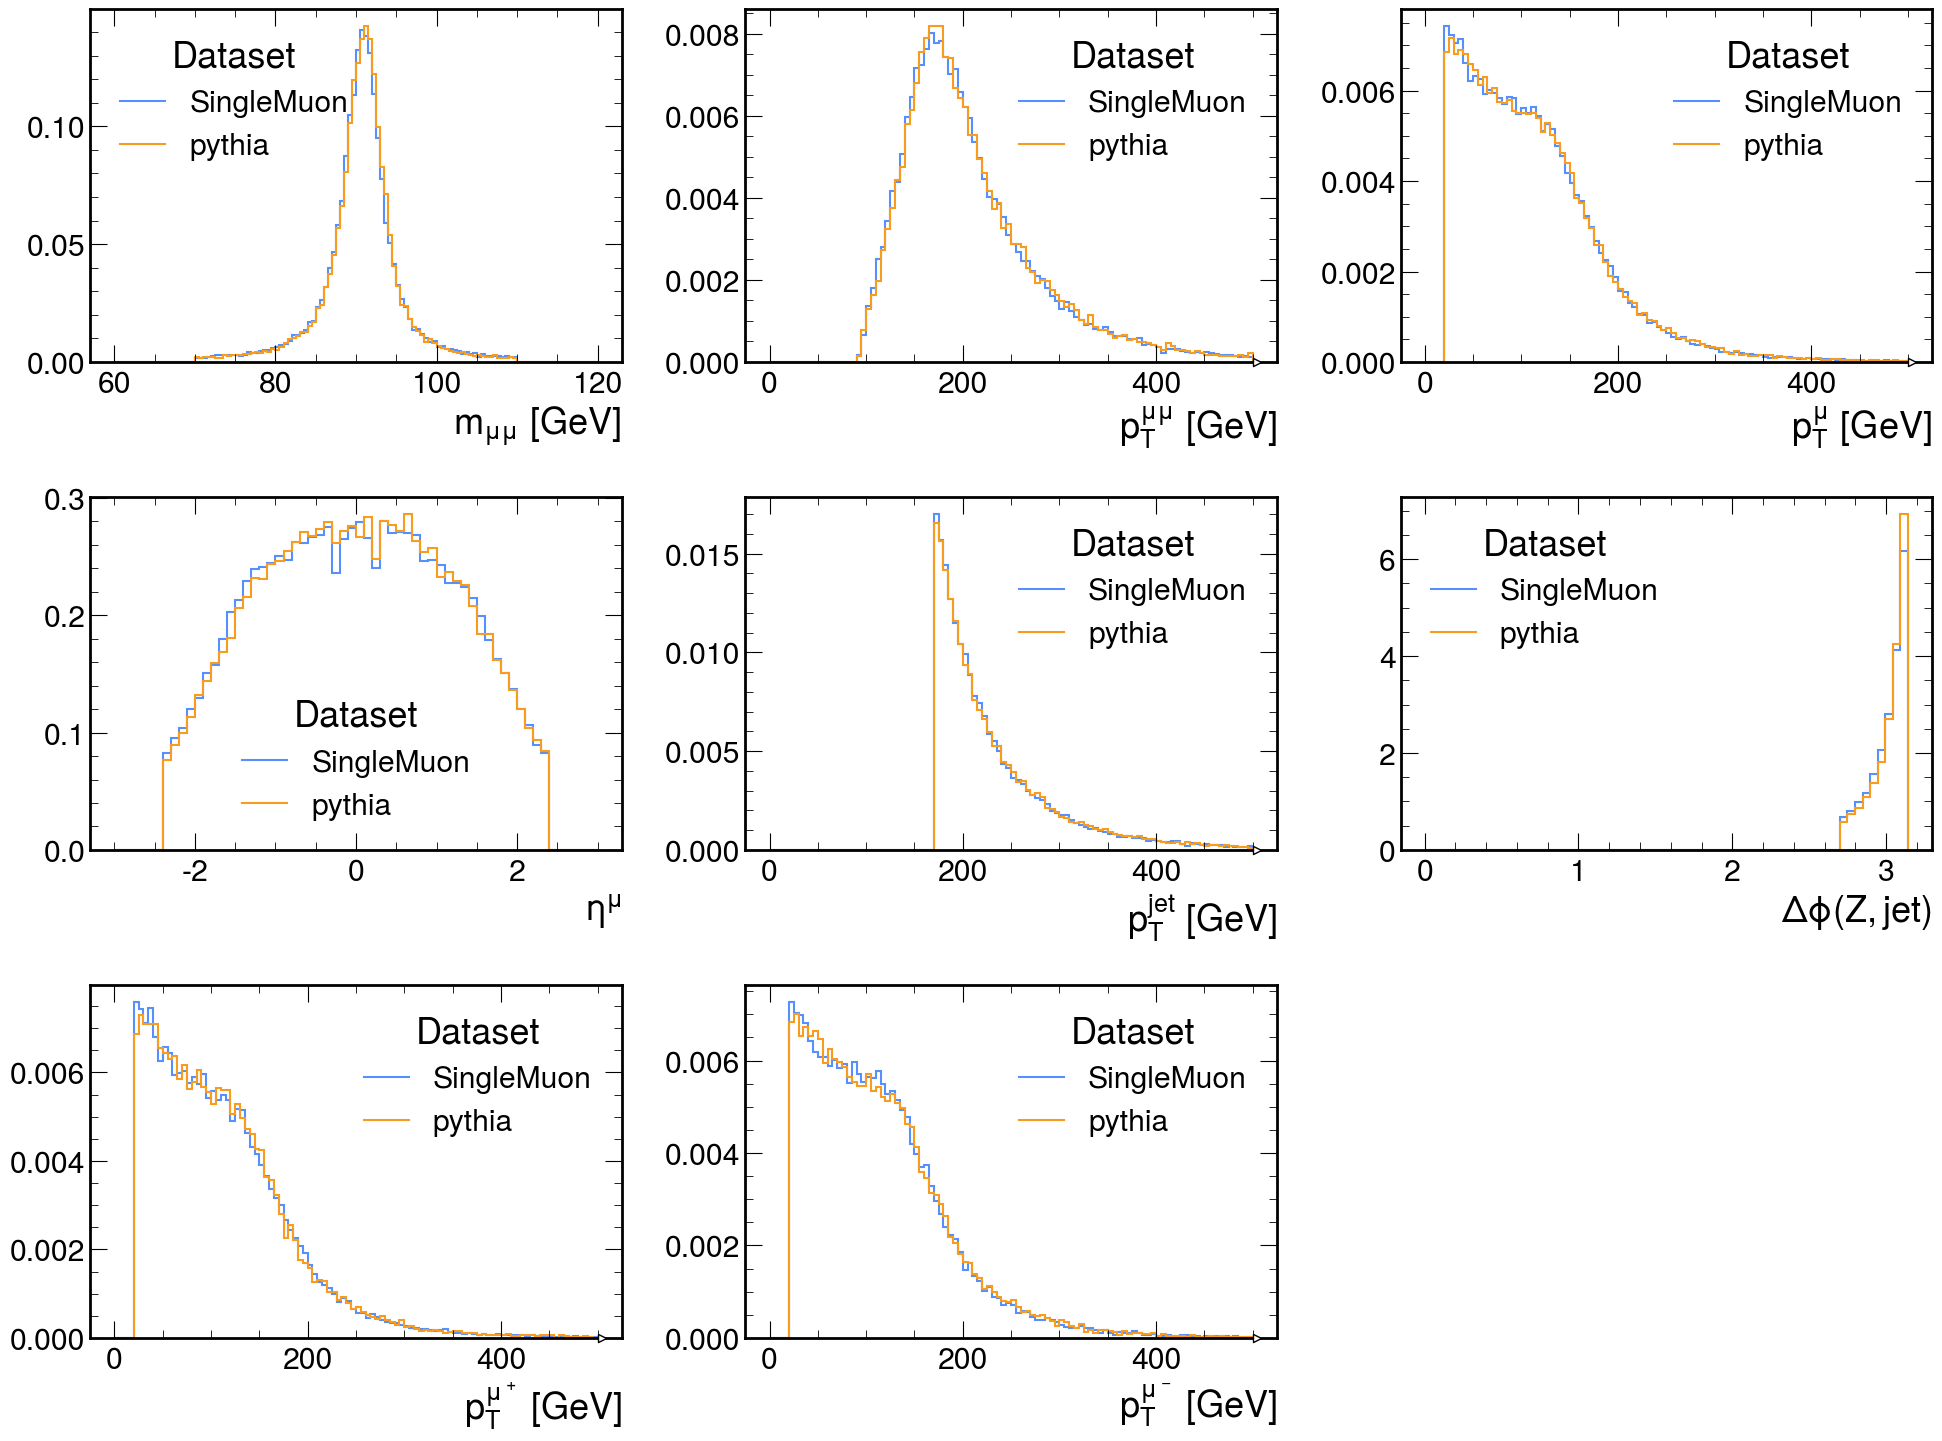

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(20, 15))

out["Z_mass"].plot(density=True, ax=axes[0, 0])
out["Z_pt"].plot(density=True, ax=axes[0, 1])
out["mu_pt"].plot(density=True, ax=axes[0, 2])
out["mu_eta"].plot(density=True, ax=axes[1, 0])
out["jet_pt"].plot(density=True, ax=axes[1, 1])
out["dphi_Z_jet"].plot(density=True, ax=axes[1, 2])
out["mu_pt_pos"].plot(density=True, ax=axes[2, 0])
out["mu_pt_neg"].plot(density=True, ax=axes[2, 1])

axes[2, 2].axis("off")

plt.tight_layout()
plt.show()